In [519]:
from collections import Counter
from datetime import datetime
from itertools import combinations, product
from pathlib import Path
import itertools
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse, stats
from scipy.stats import chi2
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import HessianInversionWarning, ConvergenceWarning

from sklearn import tree
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    make_scorer,
    roc_auc_score,
    roc_curve,
    precision_score, 
    recall_score
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, label_binarize
from sklearn.tree import DecisionTreeClassifier, _tree

from numpy.random import default_rng
import joblib
import patsy

In [520]:
try:
    from tqdm.auto import tqdm
    _HAS_TQDM = True
except Exception:
    _HAS_TQDM = False
    def tqdm(x, **k):  # no-op fallback
        return x

def _iter_prog(iterable, total=None, desc=None,
               progress=False, leave=False, position=0,
               every=None):
    """
    Wrap an iterable with tqdm when progress is truthy; otherwise return the iterable.
    `every` maps to tqdm's `miniters` so the bar updates every N iterations.
    Falls back to the raw iterable if tqdm isn't available.
    """
    if not progress:
        return iterable
    try:
        from tqdm import tqdm
        kwargs = dict(total=total, desc=desc, leave=leave, position=position)
        if every is not None:
            kwargs["miniters"] = int(every)
        return tqdm(iterable, **kwargs)
    except Exception:
        return iterable

## Preprocesses

In [521]:
open_ended = pd.read_csv("./all_open_ended_for_models.csv")
full_combined = pd.read_csv('./full_combined_normed_exp1_add12.csv', index_col=0)

In [522]:
full_combined.rename(columns={'Response': 'gender_label'}, inplace=True)
full_combined['gender_label'].unique()

array(['cis woman', 'non-binary (AFAB)', 'trans woman', 'non-binary',
       'trans man', 'non-binary (AMAB)', 'cis man'], dtype=object)

In [523]:
full_combined['sexuality_label'] = full_combined['combined'].str.extract(r'_([^_]+)$')
full_combined['sexuality_label'].unique()

array(['straight', 'lesbian', 'bi+ (bi, pan, etc.)', 'asexual/aromantic',
       'gay'], dtype=object)

In [524]:
suffixes = ("_x", "_y", ".1")
base_names = [c.replace("_x", "").replace("_y", "").replace(".1", "") for c in open_ended.columns]
dupes = [name for name, count in Counter(base_names).items() if count > 1]
print("Columns that appear with suffixes:", dupes[:20])

Columns that appear with suffixes: ['participant_place_origin', 'participant_ses', 'participant_language', 'participant_gender', 'participant_med_affirm', 'participant_sexuality', 'participant_race_eth', 'Multiple Choice object-25 Quantised_Demographics', 'Bay_Area_check', 'trans_interact', 'gender_typical', 'masculine', 'feminine', 'social_support', 'figures_support', 'sexuality_community', 'personal_rep', 'sexuality_rep', 'community_rep', 'speech_attitude']


In [525]:
def clean_repeats(df):
    keep_cols = []
    seen = set()

    for c in df.columns:
        # base name without typical merge suffixes
        base = re.sub(r'(_x|_y|\.1)$', '', c)
        if base not in seen:
            # prefer first seen (_x over _y over .1)
            keep_cols.append(c)
            seen.add(base)
    # subset + rename to base names
    df = df[keep_cols].copy()
    df.columns = [re.sub(r'(_x|_y|\.1)$', '', c) for c in df.columns]
    return df

open_ended = clean_repeats(open_ended)
print("Remaining columns:", len(open_ended.columns))

Remaining columns: 81


In [526]:
open_ended['participant_id'].nunique(), full_combined['participant_id'].nunique()

(146, 146)

In [527]:
open_ended.columns

Index(['participant_id', 'Participant Public ID', 'Task Name',
       'randomiser-9y4r', 'Response Type', 'Correct', 'Spreadsheet: stimuli',
       'Spreadsheet: practice_stimulus', 'Spreadsheet: stimuli_group',
       'stimuli_clean', 'stimuli_type_narrow', 'stimuli_type_coarse',
       'race_ses_cond', 'Response', 'Confidence', 'normalized_response',
       'gender_label', 'sexuality_label', 'identity',
       'stimuli_clean_collapsed', 'stim_group', 'stim_type',
       'participant_place_origin', 'participant_ses', 'participant_language',
       'participant_gender', 'participant_med_affirm', 'participant_sexuality',
       'participant_race_eth',
       'Multiple Choice object-25 Quantised_Demographics', 'Bay_Area_check',
       'trans_interact', 'gender_typical', 'masculine', 'feminine',
       'social_support', 'figures_support', 'sexuality_community',
       'personal_rep', 'sexuality_rep', 'community_rep', 'speech_attitude',
       'LGBTQ_ident', 'queer_interact',
       'Text 

## Modeling
Replace minor variable names and additional preprocessing as needed to run for each outcome (to avoid risk of typos with 6 different versions of nearly identical code).

In [528]:
open_ended['identity'].value_counts()

identity
cis_woman_straight           687
cis_woman_lesbian            395
cis_woman_bisexual           277
cis_woman_unsure             180
nonbinary_bisexual           139
nonbinary_asexual             38
trans_woman_lesbian           37
cis_woman_asexual             34
cis_man_unsure                33
nonbinary_lesbian             31
unsure_unsure                 27
trans_woman_unsure            26
trans_man_straight            26
nonbinary_gay                 25
trans_woman_bisexual          23
trans_woman_straight          22
cis_man_gay                   21
trans_man_gay                 20
unsure_straight               19
nonbinary_unsure              16
trans_man_bisexual            13
cis_woman_multiple            12
unsure_bisexual               12
unsure_lesbian                11
trans_bisexual                 9
nonbinary_straight             8
unsure_gay                     5
cis_man_straight               5
cis_man_bisexual               4
trans_man_unsure               4
n

In [529]:
# min 4 per group
open_ended['identity'] = open_ended['identity'].replace({
    'agender_bisexual': 'nonbinary_bisexual',
    'nonbinary (afab)_bisexual': 'nonbinary_bisexual',
    'trans_lesbian': 'trans_woman_lesbian',
    'multiple_bisexual': 'unsure_bisexual',
    'nonbinary_multiple': 'nonbinary_unsure',
    'agender_asexual': 'nonbinary_asexual',
    'trans_gay': 'trans_man_gay',
    'nonbinary (afab)_gay': 'nonbinary_gay',
    'multiple_straight': 'unsure_straight',
    'multiple_lesbian': 'unsure_lesbian',
    'multiple_asexual': 'nonbinary_asexual',
    'trans_woman_asexual': 'trans_woman_unsure',
    'unsure_gay': 'unsure_unsure',
    'nonbinary (afab)_asexual': 'nonbinary_asexual',
    'trans_straight': 'trans_unsure',
    'trans_man_unsure': 'trans_unsure'
})

In [530]:
full_combined['combined'] = full_combined['combined'].replace({
    'cis man_lesbian': 'trans man_lesbian'})

### Ensure more than 1 participant per predictor level

#### Categorical

In [531]:
full_combined['combined'].value_counts(ascending=False)

combined
cis woman_straight                       760
cis woman_lesbian                        406
cis woman_bi+ (bi, pan, etc.)            258
non-binary_bi+ (bi, pan, etc.)            93
non-binary (AFAB)_bi+ (bi, pan, etc.)     90
trans woman_lesbian                       72
trans woman_bi+ (bi, pan, etc.)           63
non-binary_asexual/aromantic              41
trans woman_straight                      39
trans man_gay                             38
cis woman_asexual/aromantic               37
non-binary (AFAB)_lesbian                 32
trans man_straight                        27
cis woman_gay                             26
cis man_gay                               25
non-binary (AFAB)_gay                     25
non-binary_lesbian                        25
trans woman_gay                           24
trans man_bi+ (bi, pan, etc.)             19
non-binary (AFAB)_asexual/aromantic       15
non-binary_gay                            15
trans woman_asexual/aromantic              8
n

In [532]:
#full_combined['participant_language_normed'].value_counts()
#open_ended['participant_language_normed'].value_counts()

In [533]:
#full_combined[full_combined['participant_language_normed'] == 'English, German']['participant_id'].nunique()
#open_ended[open_ended['participant_language_normed'] == 'English, German']['participant_id'].nunique()

In [534]:
top3 = full_combined['participant_language_normed'].value_counts().nlargest(3).index
full_combined['participant_language_normed'] = full_combined['participant_language_normed'].where(
    full_combined['participant_language_normed'].isin(top3), 'Other'
)
full_combined['participant_language_normed'].value_counts()
top3_1 = open_ended['participant_language_normed'].value_counts().nlargest(3).index
open_ended['participant_language_normed'] = open_ended['participant_language_normed'].where(
    open_ended['participant_language_normed'].isin(top3_1), 'Other'
)
open_ended['participant_language_normed'].value_counts()

participant_language_normed
English             1290
Other                510
English, Spanish     300
English, German       90
Name: count, dtype: int64

In [535]:
#full_combined['participant_race_eth_normed'].value_counts()
#open_ended['participant_race_eth_normed'].value_counts()

In [536]:
full_combined['participant_race_eth_normed'] = full_combined['participant_race_eth_normed'].replace(
    ['mixed race', 'Pacific Islander', 'Native American/Indigenous', 'uncategorized'],
    'mixed/API/Indigenous'
)
full_combined['participant_race_eth_normed'].value_counts()
open_ended['participant_race_eth_normed'] = open_ended['participant_race_eth_normed'].replace(
    ['mixed race', 'Pacific Islander', 'Native American/Indigenous', 'uncategorized'],
    'mixed/API/Indigenous'
)
open_ended['participant_race_eth_normed'].value_counts()

participant_race_eth_normed
white                     1140
Asian/Asian American       450
Hispanic/Latinx            285
Black/African American     240
mixed/API/Indigenous        75
Name: count, dtype: int64

In [537]:
#full_combined['participant_ses_normed'].value_counts()
#open_ended['participant_ses_normed'].value_counts()

In [538]:
full_combined['participant_place_origin_normed'] = full_combined['participant_place_origin_normed'].replace(
    ['uncategorized', 'Africa (general)'],
    'Africa/uncategorized'
)
full_combined['participant_place_origin_normed'].value_counts()
open_ended['participant_place_origin_normed'] = open_ended['participant_place_origin_normed'].replace(
    ['uncategorized', 'Africa (general)'],
    'Africa/uncategorized'
)
open_ended['participant_place_origin_normed'].value_counts()

participant_place_origin_normed
USA (general)           1080
California               600
Europe                   195
Africa/uncategorized      90
(East) Asia               75
Central America           60
Southern US               45
Midwestern US             45
Name: count, dtype: int64

In [539]:
full_combined['participant_place_origin_normed'] = full_combined['participant_place_origin_normed'].replace(
    ['Southern US', 'Midwestern US'],
    'South/Midwestern US'
)
full_combined['participant_place_origin_normed'].value_counts()
open_ended['participant_place_origin_normed'] = open_ended['participant_place_origin_normed'].replace(
    ['Southern US', 'Midwestern US'],
    'South/Midwestern US'
)
open_ended['participant_place_origin_normed'].value_counts()

participant_place_origin_normed
USA (general)           1080
California               600
Europe                   195
South/Midwestern US       90
Africa/uncategorized      90
(East) Asia               75
Central America           60
Name: count, dtype: int64

In [540]:
full_combined['participant_med_affirm_normed'] = full_combined['participant_med_affirm_normed'].replace('Unknown','No')
full_combined['participant_med_affirm_normed'].value_counts()
open_ended['participant_med_affirm_normed'] = open_ended['participant_med_affirm_normed'].replace('Unknown','No')
open_ended['participant_med_affirm_normed'].value_counts()

participant_med_affirm_normed
No     1995
Yes     195
Name: count, dtype: int64

#### Numeric

In [541]:
#full_combined['LGBTQ_ident'].value_counts().sort_index(ascending=False)
#open_ended['LGBTQ_ident'].value_counts().sort_index(ascending=False)

In [542]:
type(full_combined['LGBTQ_ident'][0])

numpy.float64

In [543]:
replacements = {
    **{k: 1.75 for k in [1.0, 1.5, 2.0, 2.5]},
    **{k: 3.75 for k in [3.0, 3.5, 4.0, 4.5]}
}
open_ended['LGBTQ_ident'] = open_ended['LGBTQ_ident'].replace(replacements)
open_ended['LGBTQ_ident'].value_counts().sort_index(ascending=False)
full_combined['LGBTQ_ident'] = full_combined['LGBTQ_ident'].replace(replacements)
full_combined['LGBTQ_ident'].value_counts().sort_index(ascending=False)

LGBTQ_ident
7.00    1020
6.50     285
6.00     390
5.50     105
5.00     167
3.75     105
1.75      90
Name: count, dtype: int64

In [544]:
#full_combined['queer_interact'].value_counts().sort_index(ascending=False)
#open_ended['queer_interact'].value_counts().sort_index(ascending=False)

In [545]:
replacements = {
    **{k: 1.75 for k in [1.0, 1.5, 2.0, 2.5]},
    **{k: 4.0 for k in [3.5, 4.0, 4.5]}
}
open_ended['queer_interact'] = open_ended['queer_interact'].replace(replacements)
open_ended['queer_interact'].value_counts().sort_index(ascending=False)
full_combined['queer_interact'] = full_combined['queer_interact'].replace(replacements)
full_combined['queer_interact'].value_counts().sort_index(ascending=False)

queer_interact
7.00    630
6.50    240
6.00    392
5.50     90
5.00    285
4.00    135
3.00    135
1.75    225
Name: count, dtype: int64

In [546]:
#open_ended['trans_interact'].value_counts().sort_index(ascending=False)
#full_combined['trans_interact'].value_counts().sort_index(ascending=False)

In [547]:
replacements = {
    **{k: 1.25 for k in [1.0, 1.5]},
    **{k: 4.25 for k in [4.0, 4.5]}
}
open_ended['trans_interact'] = open_ended['trans_interact'].replace(replacements)
open_ended['trans_interact'].value_counts().sort_index(ascending=False)
full_combined['trans_interact'] = full_combined['trans_interact'].replace(replacements)
full_combined['trans_interact'].value_counts().sort_index(ascending=False)

trans_interact
7.00    375
6.50     90
6.00    120
5.50    135
5.00    285
4.25    165
3.50    105
3.00    227
2.50    135
2.00    225
1.25    300
Name: count, dtype: int64

In [548]:
#full_combined['gender_typical'].value_counts().sort_index(ascending=False)
#open_ended['gender_typical'].value_counts().sort_index(ascending=False)

In [549]:
replacements = {
    **{k: 6.75 for k in [6.5, 7.0]},
    **{k: 3.75 for k in [3.5, 4.0]},
    **{k: 2.25 for k in [2.0, 2.5]},
    **{k: 1.25 for k in [1.0, 1.5]}
}
full_combined['gender_typical'] = full_combined['gender_typical'].replace(replacements)
full_combined['gender_typical'].value_counts().sort_index(ascending=False)
open_ended['gender_typical'] = open_ended['gender_typical'].replace(replacements)
open_ended['gender_typical'].value_counts().sort_index(ascending=False)

gender_typical
6.75    225
6.00    330
5.50    150
5.00    300
4.50    165
3.75    240
3.00    285
2.25    270
1.25    150
Name: count, dtype: int64

In [550]:
#full_combined['masculine'].value_counts().sort_index(ascending=False)
#open_ended['masculine'].value_counts().sort_index(ascending=False)

In [551]:
replacements = {
    **{k: 2.75 for k in [2.0, 2.5]},
    **{k: 6.75 for k in [6.5, 7.0]}
}
full_combined['masculine'] = full_combined['masculine'].replace(replacements)
full_combined['masculine'].value_counts().sort_index(ascending=False)
open_ended['masculine'] = open_ended['masculine'].replace(replacements)
open_ended['masculine'].value_counts().sort_index(ascending=False)

masculine
6.75     90
6.00    150
5.50    150
5.00    285
4.50    210
4.00    270
3.50    105
3.00    255
2.75    315
1.50    120
1.00    165
Name: count, dtype: int64

In [552]:
#full_combined['feminine'].value_counts().sort_index(ascending=False)
#open_ended['feminine'].value_counts().sort_index(ascending=False)

In [553]:
replacements = {
    **{k: 2.75 for k in [1.0, 1.5]}
}
full_combined['feminine'] = full_combined['feminine'].replace(replacements)
full_combined['feminine'].value_counts().sort_index(ascending=False)
open_ended['feminine'] = open_ended['feminine'].replace(replacements)
open_ended['feminine'].value_counts().sort_index(ascending=False)

feminine
7.00    135
6.50    120
6.00    255
5.50    195
5.00    255
4.50    135
4.00    135
3.50    120
3.00    225
2.75    210
2.50    120
2.00    180
Name: count, dtype: int64

In [554]:
#full_combined['social_support'].value_counts().sort_index(ascending=False)
#open_ended['social_support'].value_counts().sort_index(ascending=False)

In [555]:
replacements = {
    **{k: 4.75 for k in [4.5, 5.0]},
    **{k: 1.75 for k in [1.0, 1.5, 2.0, 2.5]},
    **{k: 4.0 for k in [3.0, 4.0, 4.5]}
}
full_combined['social_support'] = full_combined['social_support'].replace(replacements)
full_combined['social_support'].value_counts().sort_index(ascending=False)
open_ended['social_support'] = open_ended['social_support'].replace(replacements)
open_ended['social_support'].value_counts().sort_index(ascending=False)

social_support
7.00    1080
6.50     240
6.00     375
5.50      90
4.75     165
4.00      90
1.75     105
Name: count, dtype: int64

In [556]:
#full_combined['figures_support'].value_counts().sort_index(ascending=False)
#open_ended['figures_support'].value_counts().sort_index(ascending=False)

In [557]:
replacements = {
    **{k: 1.25 for k in [1.0, 1.5]}
}
full_combined['figures_support'] = full_combined['figures_support'].replace(replacements)
full_combined['figures_support'].value_counts().sort_index(ascending=False)
open_ended['figures_support'] = open_ended['figures_support'].replace(replacements)
open_ended['figures_support'].value_counts().sort_index(ascending=False)

figures_support
7.00    255
6.50    135
6.00    330
5.50    210
5.00    345
4.50    120
4.00     90
3.50     90
3.00    165
2.50     90
2.00    180
1.25    135
Name: count, dtype: int64

In [558]:
#full_combined['sexuality_community'].value_counts().sort_index(ascending=False)
#open_ended['sexuality_community'].value_counts().sort_index(ascending=False)

In [559]:
replacements = {
    **{k: 1.25 for k in [1.0, 1.5]},
    **{k: 3.0 for k in [2.5, 3.0, 3.5]}
}
full_combined['sexuality_community'] = full_combined['sexuality_community'].replace(replacements)
full_combined['sexuality_community'].value_counts().sort_index(ascending=False)
open_ended['sexuality_community'] = open_ended['sexuality_community'].replace(replacements)
open_ended['sexuality_community'].value_counts().sort_index(ascending=False)

sexuality_community
7.00    285
6.50    195
6.00    300
5.50    270
5.00    375
4.50    165
4.00    180
3.00    165
2.00    135
1.25    105
Name: count, dtype: int64

In [560]:
#full_combined['personal_rep'].value_counts().sort_index(ascending=False)
#open_ended['personal_rep'].value_counts().sort_index(ascending=False)

In [561]:
replacements = {
    **{k: 6.75 for k in [6.5, 7.0]},
    **{k: 1.25 for k in [1.0, 1.5]}
}
full_combined['personal_rep'] = full_combined['personal_rep'].replace(replacements)
full_combined['personal_rep'].value_counts().sort_index(ascending=False)
open_ended['personal_rep'] = open_ended['personal_rep'].replace(replacements)
open_ended['personal_rep'].value_counts().sort_index(ascending=False)

personal_rep
6.75    105
6.00    285
5.50    150
5.00    330
4.50    120
4.00    180
3.50    150
3.00    255
2.50    150
2.00    165
1.25    195
Name: count, dtype: int64

In [562]:
full_combined['sexuality_rep'].value_counts().sort_index(ascending=False)
open_ended['sexuality_rep'].value_counts().sort_index(ascending=False)

sexuality_rep
7.0     90
6.5    120
6.0    150
5.5    255
5.0    300
4.5    120
4.0    120
3.5    180
3.0    270
2.5    105
2.0    210
1.5     45
1.0    120
Name: count, dtype: int64

In [563]:
replacements = {
    **{k: 1.75 for k in [1.0, 1.5]}
}
full_combined['sexuality_rep'] = full_combined['sexuality_rep'].replace(replacements)
full_combined['sexuality_rep'].value_counts().sort_index(ascending=False)
open_ended['sexuality_rep'] = open_ended['sexuality_rep'].replace(replacements)
open_ended['sexuality_rep'].value_counts().sort_index(ascending=False)

sexuality_rep
7.00     90
6.50    120
6.00    150
5.50    255
5.00    300
4.50    120
4.00    120
3.50    180
3.00    270
2.50    105
2.00    210
1.75    165
Name: count, dtype: int64

In [564]:
#full_combined['community_rep'].value_counts().sort_index(ascending=False)
#open_ended['community_rep'].value_counts().sort_index(ascending=False)

In [565]:
replacements = {
    **{k: 6.75 for k in [6.5, 7.0]},
    **{k: 1.25 for k in [1.0, 1.5]}
}
full_combined['community_rep'] = full_combined['community_rep'].replace(replacements)
full_combined['community_rep'].value_counts().sort_index(ascending=False)
open_ended['community_rep'] = open_ended['community_rep'].replace(replacements)
open_ended['community_rep'].value_counts().sort_index(ascending=False)

community_rep
6.75     90
6.00    180
5.50    180
5.00    315
4.50    105
4.00    165
3.50    165
3.00    345
2.50    135
2.00    210
1.25    165
Name: count, dtype: int64

In [566]:
#full_combined['speech_attitude'].value_counts().sort_index(ascending=False)
#open_ended['speech_attitude'].value_counts().sort_index(ascending=False)

In [567]:
replacements = {
    **{k: 4.0 for k in [3.5, 4.0, 4.5]},
    **{k: 1.75 for k in [1.0, 1.5, 2.0, 3.0]}
}
full_combined['speech_attitude'] = full_combined['speech_attitude'].replace(replacements)
full_combined['speech_attitude'].value_counts().sort_index(ascending=False)
open_ended['speech_attitude'] = open_ended['speech_attitude'].replace(replacements)
open_ended['speech_attitude'].value_counts().sort_index(ascending=False)

speech_attitude
7.00    435
6.50    195
6.00    345
5.50    255
5.00    285
4.00    330
1.75    225
Name: count, dtype: int64

### Fit pipeline

In [568]:
# --- Columns (your lists) ---
# 'Confidence' for open_ended
ordinal_numeric = [
    'LGBTQ_ident','queer_interact','trans_interact','Confidence',
    'gender_typical','masculine','feminine',
    'social_support','figures_support','sexuality_community',
    'personal_rep','sexuality_rep','community_rep',
    'speech_attitude'
]

# 'gender_label', 'sexuality_label'
categorical = [
    'stimuli_clean','race_ses_cond',
    'Bay_Area_check', 'participant_gender_restrictive',
    'participant_sexuality_normed', 'participant_language_normed',
    'participant_ses_normed','participant_race_eth_normed',
    'participant_place_origin_normed','participant_med_affirm_normed'
]

categorical = [c for c in categorical if c in open_ended.columns]
ordinal_numeric = [c for c in ordinal_numeric if c in open_ended.columns]
# categorical = [c for c in categorical if c in full_combined.columns]
# ordinal_numeric = [c for c in ordinal_numeric if c in full_combined.columns]
predictors = categorical + ordinal_numeric
sorted(predictors)

['Bay_Area_check',
 'Confidence',
 'LGBTQ_ident',
 'community_rep',
 'feminine',
 'figures_support',
 'gender_typical',
 'masculine',
 'participant_gender_restrictive',
 'participant_language_normed',
 'participant_med_affirm_normed',
 'participant_place_origin_normed',
 'participant_race_eth_normed',
 'participant_ses_normed',
 'participant_sexuality_normed',
 'personal_rep',
 'queer_interact',
 'race_ses_cond',
 'sexuality_community',
 'sexuality_rep',
 'social_support',
 'speech_attitude',
 'stimuli_clean',
 'trans_interact']

In [569]:
# full_combined['combined'].value_counts()

In [570]:
X = open_ended[predictors].copy()
y = open_ended['identity']
# X = full_combined[predictors].copy()
# y = full_combined['combined']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- Preprocessor (FIX: impute cats before OHE) ---
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean'))
        ]), ordinal_numeric)
    ],
    remainder='drop'
)

In [571]:
clf = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'))
])

clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['stimuli_clean',
                                                   'race_ses_cond',
                                                   'Bay_Area_check',
                                                   'participant_gender_restrictive',
                                                   'participant_sexuality_normed',
                                                   'participant_language_normed',
                                                   'participant_ses_n...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer())]),
                                                  ['LGBTQ_ident',
                                                   'queer_interact',
                                                   'trans_interact',
                                                   'Confidence',
                                                   'gender_typical',
                                                   'masculine', 'feminine',
                                                   'social_support',
                                                   'figures_support',
                                                   'sexuality_community',
                                                   'personal_rep',
                                                   'sexuality_rep',
                                                   'community_rep',
                                                   'speech_attitude'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

### Grid search hyperparameters

In [508]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    'rf__n_estimators': [200, 500, 800],
    'rf__max_depth': [None, 15, 25],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 5],
    'rf__max_features': ['sqrt', 'log2', 0.3],
    'rf__class_weight': [None, 'balanced'],
}

gs = GridSearchCV(
    clf,
    param_grid,
    cv=cv,
    scoring='roc_auc_ovr_weighted',
    n_jobs=-1,
    verbose=3,
    refit=True
)

gs.fit(X_train, y_train)

Fitting 3 folds for each of 486 candidates, totalling 1458 fits


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['stimuli_clean',
                                                                          'race_ses_cond',
                                                                          'Bay_Area_check',
                                                                          'participant_gender_restricti...
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_estimators=300,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'rf__class_weight': [None, 'balanced'],
                         'rf__max_depth': [None, 15, 25],
                         'rf__max_features': ['sqrt', 'log2', 0.3],
                         'rf__min_samples_leaf': [1, 2, 5],
                         'rf__min_samples_split': [2, 5, 10],
                         'rf__n_estimators': [200, 500, 800]},
             scoring='roc_auc_ovr_weighted', verbose=3)

In [509]:
def eval_metrics(clf, X, y):
    """Compute accuracy, AUCs, precision, recall, and F1 (macro & weighted)."""
    yhat  = clf.predict(X)
    proba = clf.predict_proba(X)
    labels = clf.named_steps['rf'].classes_
    return {
        # --- classification ---
        "acc": accuracy_score(y, yhat),
        "prec_macro": precision_score(y, yhat, average="macro", zero_division=0),
        "rec_macro":  recall_score(y, yhat, average="macro", zero_division=0),
        "f1_macro":   f1_score(y, yhat, average="macro", zero_division=0),
        "prec_weighted": precision_score(y, yhat, average="weighted", zero_division=0),
        "rec_weighted":  recall_score(y, yhat, average="weighted", zero_division=0),
        "f1_weighted":   f1_score(y, yhat, average="weighted", zero_division=0),
        # --- AUCs ---
        "auc_weighted_ovr": roc_auc_score(y, proba, multi_class="ovr", average="weighted", labels=labels),
        "auc_micro_ovr":    roc_auc_score(y, proba, multi_class="ovr", average="micro",    labels=labels),
        "auc_macro_ovr":    roc_auc_score(y, proba, multi_class="ovr", average="macro",    labels=labels),
    }

def fmt(m):
    return (f"Acc={m['acc']:.3f} | "
            f"P_macro={m['prec_macro']:.3f} | R_macro={m['rec_macro']:.3f} | F1_macro={m['f1_macro']:.3f} || "
            f"P_wt={m['prec_weighted']:.3f} | R_wt={m['rec_weighted']:.3f} | F1_wt={m['f1_weighted']:.3f} || "
            f"AUC_w={m['auc_weighted_ovr']:.3f} | AUC_micro={m['auc_micro_ovr']:.3f} | AUC_macro={m['auc_macro_ovr']:.3f}")

def print_rows(rows):
    for name, part, metrics in rows:
        print(f"{name:16s} {part:5s}  {fmt(metrics)}")

# --- (A) Best from grid (refit=True so already trained) ---
best_clf = gs.best_estimator_
best_train = eval_metrics(best_clf, X_train, y_train)
best_test  = eval_metrics(best_clf, X_test,  y_test)

# --- (B) Forced balanced class weights ---
forced_bal = clone(best_clf).set_params(rf__class_weight='balanced')
forced_bal.fit(X_train, y_train)
forced_train = eval_metrics(forced_bal, X_train, y_train)
forced_test  = eval_metrics(forced_bal, X_test,  y_test)

# --- Pretty print ---
print("\n=== Grid Best vs. Forced Balanced — Train/Test ===")
print_rows([
    ("Grid Best",       "train", best_train),
    ("Grid Best",       "test",  best_test),
    ("Forced Balanced", "train", forced_train),
    ("Forced Balanced", "test",  forced_test),
])

# --- Select winner (priority: test weighted OvR AUC, then test macro F1, then accuracy) ---
def key(m): 
    return (m["auc_weighted_ovr"], m["f1_macro"], m["acc"])

winner = "forced_balanced" if key(forced_test) > key(best_test) else "grid_best"
final_clf = forced_bal if winner == "forced_balanced" else best_clf
print(f"\nWinner → {winner} (priority = test weighted OvR AUC → macro F1 → accuracy)")


=== Grid Best vs. Forced Balanced — Train/Test ===
Grid Best        train  Acc=0.963 | P_macro=0.975 | R_macro=0.916 | F1_macro=0.940 || P_wt=0.965 | R_wt=0.963 | F1_wt=0.962 || AUC_w=0.998 | AUC_micro=0.999 | AUC_macro=1.000
Grid Best        test   Acc=0.481 | P_macro=0.242 | R_macro=0.206 | F1_macro=0.205 || P_wt=0.445 | R_wt=0.481 | F1_wt=0.451 || AUC_w=0.828 | AUC_micro=0.937 | AUC_macro=0.818
Forced Balanced  train  Acc=0.881 | P_macro=0.770 | R_macro=0.975 | F1_macro=0.850 || P_wt=0.907 | R_wt=0.881 | F1_wt=0.884 || AUC_w=0.991 | AUC_micro=0.998 | AUC_macro=0.998
Forced Balanced  test   Acc=0.449 | P_macro=0.275 | R_macro=0.372 | F1_macro=0.289 || P_wt=0.495 | R_wt=0.449 | F1_wt=0.461 || AUC_w=0.807 | AUC_micro=0.923 | AUC_macro=0.792

Winner → grid_best (priority = test weighted OvR AUC → macro F1 → accuracy)


In [510]:
best_clf.named_steps['rf'].criterion

'gini'

In [572]:
print(gs.best_params_)
print(gs.best_score_)

{'rf__class_weight': None, 'rf__max_depth': None, 'rf__max_features': 0.3, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 500}
0.7785033759295854


### AUROC

Micro AUC: 0.937 | Macro AUC: 0.818


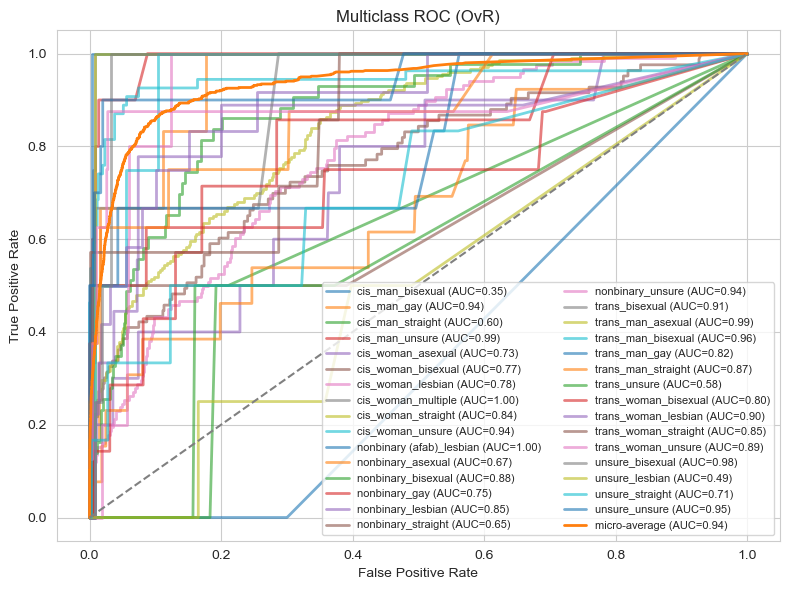

Weighted OvR AUC: 0.828 | Micro OvR AUC: 0.937 | Macro OvR AUC: 0.818


In [512]:
# --- Use the tuned estimator consistently ---
clf = gs.best_estimator_

# 1) Predictions / classes
classes = clf.named_steps['rf'].classes_
proba   = clf.predict_proba(X_test)
Y_test  = label_binarize(y_test, classes=classes)

# 2) Per-class OvR ROC curves
fprs, tprs, rocs, valid_classes = {}, {}, {}, []
for i, cls in enumerate(classes):
    y_true_bin = Y_test[:, i]
    if np.unique(y_true_bin).size < 2:
        continue
    fpr_i, tpr_i, _ = roc_curve(y_true_bin, proba[:, i])
    fprs[cls], tprs[cls] = fpr_i, tpr_i
    rocs[cls] = auc(fpr_i, tpr_i)
    valid_classes.append(cls)

# 3) Micro/macro averages
if valid_classes:
    valid_mask = np.isin(classes, valid_classes)
    fpr_micro, tpr_micro, _ = roc_curve(
        Y_test[:, valid_mask].ravel(),
        proba[:,  valid_mask].ravel()
    )
    auc_micro = auc(fpr_micro, tpr_micro)
    auc_macro = float(np.mean(list(rocs.values())))
else:
    fpr_micro = tpr_micro = np.array([])
    auc_micro = np.nan
    auc_macro = np.nan

print(f"Micro AUC: {auc_micro:.3f} | Macro AUC: {auc_macro:.3f}")

# 4) Plot
plt.figure(figsize=(8,6))
for cls in valid_classes:
    plt.plot(fprs[cls], tprs[cls], lw=2, alpha=0.6,
             label=f'{cls} (AUC={rocs[cls]:.2f})')
if valid_classes:
    plt.plot(fpr_micro, tpr_micro, lw=2, label=f'micro-average (AUC={auc_micro:.2f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC (OvR)')
plt.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

# 5) Single-number summaries
auc_weighted_ovr = roc_auc_score(y_test, proba, multi_class='ovr', average='weighted', labels=classes)
auc_micro_skl    = roc_auc_score(y_test, proba, multi_class='ovr', average='micro',    labels=classes)
auc_macro_skl    = roc_auc_score(y_test, proba, multi_class='ovr', average='macro',    labels=classes)
print(f'Weighted OvR AUC: {auc_weighted_ovr:.3f} | Micro OvR AUC: {auc_micro_skl:.3f} | Macro OvR AUC: {auc_macro_skl:.3f}')

### Predict on test set

In [573]:
final_clf = gs.best_estimator_
final_clf.fit(X_train, y_train)

y_pred  = final_clf.predict(X_test)
y_proba = final_clf.predict_proba(X_test)

# 4) Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=final_clf.classes_))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=final_clf.classes_, zero_division=0))

Accuracy: 0.4809741248097412

Confusion Matrix:
[[  0   0   0   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   1   3   0   1   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   1   0   0   0   0]
 [  0   0   0   0   0   0   0   0   2   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   7   0   0   0   0   0   3   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   1   6   0   3   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0  31  13   2  30   0   1   1   4   0   0   0   0   0
    0   0   0   0   0   0   1   0   0   0   0   0   0]
 [  0   0   0   0   1   8  49   0  47   2   0   0   6   0   3   0   0   0
    0   0   0   0   0   0   2   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   3   1   0   0   0

#### Counts

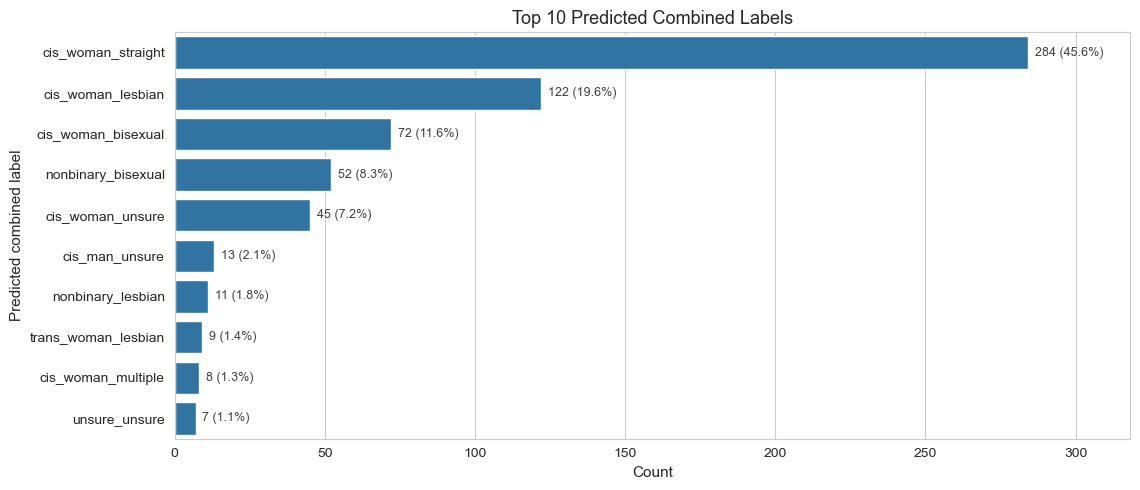

In [574]:
import seaborn as sns

# --- Count predicted gender_label frequencies ---
freq = Counter(y_pred)             # or use open_ended['gender_label'] for ground truth
top_n = freq.most_common(10)       # top 10 most frequent predictions

# --- Convert to DataFrame for seaborn ---
labels, counts = zip(*top_n)
df_freq = pd.DataFrame({'identity': labels, 'count': counts})

# --- Plot ---
plt.figure(figsize=(11.5, 5))
single_color = sns.color_palette("tab20")[0]
ax = sns.barplot(x='count', y='identity', data=df_freq, orient='h',
                 color=single_color)

# Add a little padding for annotations
ax.set_xlim(0, df_freq['count'].max() * 1.12)

# Annotate each bar with "count (pct%)"
total = df_freq['count'].sum()
for p in ax.patches:
    w = p.get_width()
    y = p.get_y() + p.get_height() / 2
    pct = (w / total * 100.0) if total else 0.0
    ax.annotate(f"{int(w)} ({pct:.1f}%)",
                xy=(w, y), xytext=(5, 0), textcoords="offset points",
                va="center", ha="left", fontsize=9, color="0.25")

# --- Labels and styling ---
ax.set_xlabel("Count", fontsize=11)
ax.set_ylabel("Predicted combined label", fontsize=11)
ax.set_title("Top 10 Predicted Combined Labels", fontsize=13)
plt.tight_layout()
plt.show()

In [515]:
open_ended.head()

,participant_id,Participant Public ID,Task Name,randomiser-9y4r,Response Type,Correct,Spreadsheet: stimuli,Spreadsheet: practice_stimulus,Spreadsheet: stimuli_group,stimuli_clean,...,community_rep_rounded,speech_attitude_rounded,normalized_participant_gender,participant_gender_restrictive,participant_sexuality_normed,participant_language_normed,participant_ses_normed,participant_race_eth_normed,participant_place_origin_normed,participant_med_affirm_normed
0,13879027.0,66e12593ddd5a01785c4e288,Social judgements task,race_ses_9,response,0.0,S01_I-said-anything_formal-breathiness_0_mono-...,NaN,1.0,modal (said),...,3.0,7.0,cisgender man,cisgender man,bi+,English,middle_income,Hispanic/Latinx,California,No
1,13879027.0,66e12593ddd5a01785c4e288,Social judgements task,race_ses_9,response,0.0,S01_I-said-anything_formal-breathiness_0_mono-...,NaN,1.0,breathy low (said),...,3.0,7.0,cisgender man,cisgender man,bi+,English,middle_income,Hispanic/Latinx,California,No
2,13879027.0,66e12593ddd5a01785c4e288,Social judgements task,race_ses_9,response,0.0,S01_I-said-anything_formal-breathiness_0_mono-...,NaN,1.0,breathy high (said),...,3.0,7.0,cisgender man,cisgender man,bi+,English,middle_income,Hispanic/Latinx,California,No
3,13879027.0,66e12593ddd5a01785c4e288,Social judgements task,race_ses_9,response,0.0,S01_I-said-anything_formal_mono-changesemitone...,NaN,1.0,creaky low (said),...,3.0,7.0,cisgender man,cisgender man,bi+,English,middle_income,Hispanic/Latinx,California,No
4,13879027.0,66e12593ddd5a01785c4e288,Social judgements task,race_ses_9,response,0.0,S01_I-said-anything_formal_mono-changesemitone...,NaN,1.0,creaky high (said),...,3.0,7.0,cisgender man,cisgender man,bi+,English,middle_income,Hispanic/Latinx,California,No


In [516]:
full_combined.columns.tolist()

['participant_id',
 'Participant Public ID',
 'Task Name',
 'randomiser-9y4r',
 'Response Type',
 'gender_label',
 'Correct',
 'Spreadsheet: stimuli',
 'Spreadsheet: practice_stimulus',
 'Spreadsheet: stimuli_group',
 'subtask',
 'stimuli_clean',
 'stimuli_type_narrow',
 'stimuli_type_coarse',
 'race_ses_cond',
 'participant_place_origin',
 'participant_ses',
 'participant_language',
 'participant_gender',
 'participant_med_affirm',
 'participant_sexuality',
 'participant_race_eth',
 'Multiple Choice object-25 Quantised_Demographics',
 'Bay_Area_check',
 'trans_interact',
 'gender_typical',
 'masculine',
 'feminine',
 'social_support',
 'figures_support',
 'sexuality_community',
 'personal_rep',
 'sexuality_rep',
 'community_rep',
 'speech_attitude',
 'LGBTQ_ident',
 'queer_interact',
 'Text Entry object-12 Value_Post-task questionnaire',
 'Text Entry object-15 Value_Post-task questionnaire',
 'Text Entry object-18 Value_Post-task questionnaire',
 'Text Entry object-21 Value_Post-task 

Top-2 predicted labels: ['cis_woman_straight', 'cis_woman_lesbian']


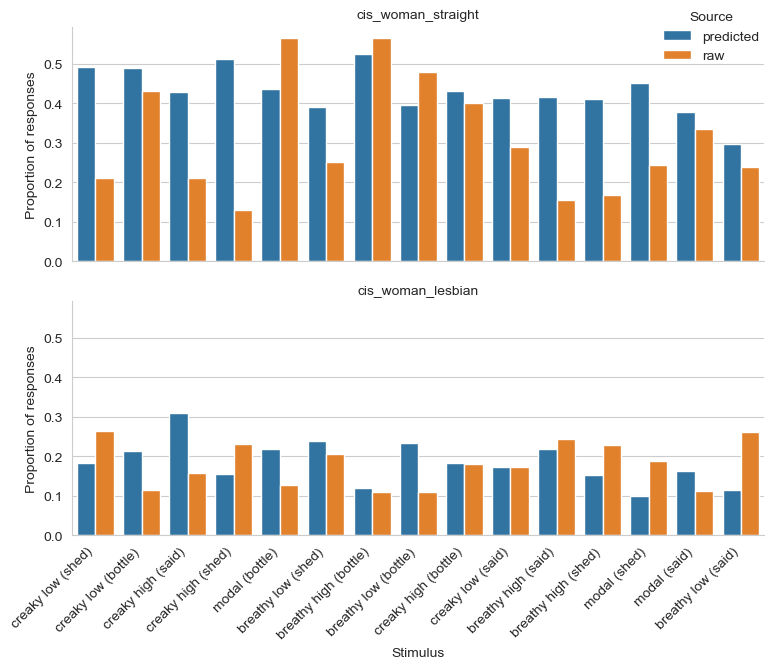

In [517]:
label_col = "identity"          # <-- CHANGE to "combined" when needed
raw_source = open_ended if label_col == "identity" else full_combined

# -----------------------------------------------------------
# 0. Align data to test rows
# -----------------------------------------------------------
idx = X_test.index

# Raw labels on test indices
df_raw = raw_source.loc[idx, ['stimuli_clean', label_col]].copy()
df_raw['source'] = 'raw'

# Predicted labels on the same rows (always from full_combined for stimuli)
df_pred = full_combined.loc[idx, ['stimuli_clean']].copy()
df_pred[label_col] = y_pred
df_pred['source'] = 'predicted'

# Stack raw + predicted
df_all = pd.concat([df_raw, df_pred], ignore_index=True)

# -----------------------------------------------------------
# 1. Top-2 predicted labels (based on this model's label column)
# -----------------------------------------------------------
top2_pred_labels = (
    df_pred[label_col]
    .value_counts()
    .head(2)
    .index
)

print("Top-2 predicted labels:", top2_pred_labels.tolist())

# -----------------------------------------------------------
# 2. Totals per stimulus × source (for normalization)
#    Includes *all* labels, not just top-2
# -----------------------------------------------------------
totals = (
    df_all
    .groupby(['stimuli_clean', 'source'])
    .size()
    .reset_index(name='total')
)

# -----------------------------------------------------------
# 3. Counts for top-2 labels only
# -----------------------------------------------------------
df_plot = (
    df_all[df_all[label_col].isin(top2_pred_labels)]
    .groupby(['stimuli_clean', label_col, 'source'])
    .size()
    .reset_index(name='count')
)

# Merge in totals so we can compute proportions
df_plot = df_plot.merge(
    totals,
    on=['stimuli_clean', 'source'],
    how='left'
)

# Proportion of responses for this label
df_plot['prop'] = df_plot['count'] / df_plot['total']

# -----------------------------------------------------------
# 4. Order stimuli by total predicted count (nicer plotting)
# -----------------------------------------------------------
stim_order = (
    df_plot[df_plot['source'] == 'predicted']
    .groupby('stimuli_clean')['count']
    .sum()
    .sort_values(ascending=False)
    .index
)

# -----------------------------------------------------------
# 5. Plot: ONE column, TWO rows (one row per label)
#    y = prop, hue = source (raw/predicted)
# -----------------------------------------------------------
sns.set_style("whitegrid")

g = sns.catplot(
    data=df_plot,
    x='stimuli_clean',
    y='prop',
    hue='source',              # legend: raw vs predicted
    row=label_col,             # one row per top label (identity or combined)
    row_order=top2_pred_labels,
    kind='bar',
    order=stim_order,
    height=3.4,
    aspect=2.0,
    sharex=True,
    sharey=True,               # same y-scale (0–1) across rows
)

# Titles: use the label name for each row
g.set_titles("{row_name}")

# Rotate x-ticks 45° on bottom row only
for ax in g.axes[-1]:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Legend: inside, upper-right
leg = g._legend
leg.set_title("Source")
leg.loc = "upper right"
leg.set_bbox_to_anchor((0.98, 0.93))

# Final formatting
g.set_axis_labels("Stimulus", "Proportion of responses")
plt.tight_layout()
plt.show()


In [376]:
# -----------------------------------------------------------
# Align X_test → full_combined to get the stimuli per row
# -----------------------------------------------------------

stim_test = full_combined.loc[X_test.index, "stimuli_clean"]

df_eval = pd.DataFrame({
    "stimuli_clean": stim_test,
    "y_true": y_test,
    "y_pred": y_pred
})

# -----------------------------------------------------------
# Compute per-stimulus metrics
# -----------------------------------------------------------

rows = []

for stim, sub in df_eval.groupby("stimuli_clean"):

    y_t = sub["y_true"]
    y_p = sub["y_pred"]

    # Avoid warnings for missing classes by forcing label set
    labels = final_clf.classes_

    acc  = accuracy_score(y_t, y_p)
    prec = precision_score(y_t, y_p, labels=labels, average="macro", zero_division=0)
    rec  = recall_score(y_t, y_p, labels=labels, average="macro", zero_division=0)
    f1   = f1_score(y_t, y_p, labels=labels, average="macro", zero_division=0)

    rows.append({
        "stimuli_clean": stim,
        "accuracy": acc,
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1,
        "support": len(sub)
    })

stim_metrics = pd.DataFrame(rows).sort_values("f1_macro", ascending=False)
stim_metrics.sort_values(by='accuracy', ascending=False)

,stimuli_clean,accuracy,precision_macro,recall_macro,f1_macro,support
9,creaky low (bottle),0.638298,0.164049,0.151075,0.153117,47
12,modal (bottle),0.586957,0.211290,0.210349,0.209631,46
0,breathy high (bottle),0.547619,0.177273,0.192045,0.169432,42
14,modal (shed),0.525000,0.103943,0.106221,0.102658,40
7,creaky high (said),0.523810,0.069341,0.074117,0.071259,42
4,breathy low (said),0.522727,0.203598,0.211943,0.197000,44
13,modal (said),0.513514,0.092627,0.095699,0.094045,37
3,breathy low (bottle),0.488372,0.172992,0.163441,0.158423,43
10,creaky low (said),0.478261,0.161969,0.150358,0.150182,46
8,creaky high (shed),0.444444,0.118213,0.150000,0.120466,45


### Plot a tree

top 6 predictors only?

In [449]:
# --- Permutation importance train/test with AUC scoring ---
final_clf = gs.best_estimator_
final_clf.fit(X_train, y_train)

n_repeats = 20
scoring = 'roc_auc_ovr_weighted'
res_tr = permutation_importance(final_clf, X_train, y_train,
                                n_repeats=n_repeats, random_state=42, n_jobs=-1, scoring=scoring)
res_te = permutation_importance(final_clf, X_test,  y_test,
                                n_repeats=n_repeats, random_state=42, n_jobs=-1, scoring=scoring)

imp_tr_df = pd.DataFrame(res_tr.importances.T, columns=X_train.columns)
imp_te_df = pd.DataFrame(res_te.importances.T, columns=X_test.columns)

test_means = imp_te_df.mean(axis=0).sort_values(ascending=False)
top_k = 6
top_base_feats = [c for c in test_means.index if c in X_train.columns][:top_k]
print("Top-6 predictors by test permutation importance:", top_base_feats)

Top-6 predictors by test permutation importance: ['stimuli_clean', 'trans_interact', 'queer_interact', 'personal_rep', 'participant_gender_restrictive', 'participant_sexuality_normed']


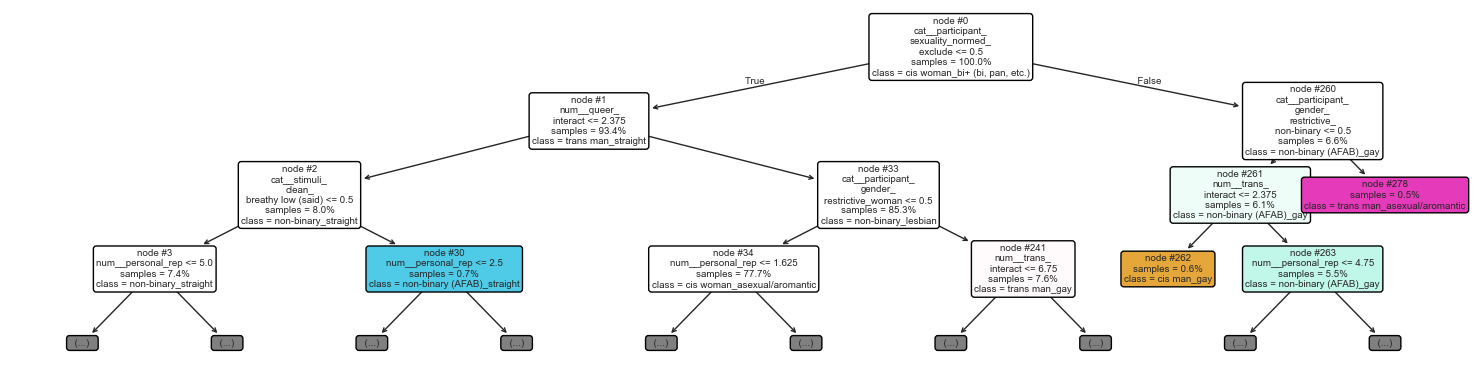

In [454]:
import matplotlib as mpl
mpl.rcParams["patch.edgecolor"] = "black"

# --- 1) Use the RF pipeline’s fitted preprocessor ---
pre_name = 'pre' if 'pre' in final_clf.named_steps else 'preprocessor'
pre = final_clf.named_steps[pre_name]
feat_names_raw = pre.get_feature_names_out()
class_names = [str(c) for c in final_clf.classes_]

# --- 2) Distill the forest -> surrogate targets ---
proba_train = final_clf.predict_proba(X_train)
y_surrogate = np.argmax(proba_train, axis=1)

# --- 3) Transform X with the fitted preprocessor ---
Xtr = pre.transform(X_train)
if sparse.issparse(Xtr):
    Xtr = Xtr.tocsc()

def feature_from_top(fname, top_feats):
    """
    Return True if this preprocessed column name corresponds to any
    of the original predictors in `top_feats`.
    Works for both numeric (num__feat) and OHE (cat__feat_level).
    """
    # We rely on the 'transformer__feature' pattern.
    # Just check if "__<orig>_" appears, or it ends with "__<orig>".
    for col in top_feats:
        token = f"__{col}"
        if fname.endswith(token) or f"{token}_" in fname:
            return True
    return False

mask = np.array([feature_from_top(fn, top_base_feats) for fn in feat_names_raw])
if not mask.any():
    raise ValueError("Mask for top features is empty – check name matching.")

Xtr_top = Xtr[:, mask]
feat_names_raw_top = feat_names_raw[mask]

# --- 4) Fit a deeper surrogate using ONLY top-6 predictors ---
surrogate_full = DecisionTreeClassifier(
    max_depth=None,          # allow full growth
    min_samples_leaf=5,      # small smoothing helps readability
    random_state=42,
    class_weight='balanced'
)
surrogate_full.fit(Xtr_top, y_surrogate)

# --- 5) Helpers to summarize hidden subtrees at the truncation frontier ---
def summarize_hidden(estimator, frontier_depth, class_names):
    t = estimator.tree_
    left, right = t.children_left, t.children_right
    n_nodes = t.node_count

    # Compute depth for each node
    depth = np.zeros(n_nodes, dtype=int)
    stack = [(0, 0)]
    while stack:
        nid, d = stack.pop()
        depth[nid] = d
        if left[nid] != _tree.TREE_LEAF:
            stack.append((left[nid], d + 1))
            stack.append((right[nid], d + 1))

    info = {}
    for nid in range(n_nodes):
        # Nodes at the frontier with children (truncated in the plot)
        if depth[nid] == frontier_depth and left[nid] != _tree.TREE_LEAF:
            # Collect all descendant leaves
            leaves, st = [], [nid]
            nodes_below = 0
            while st:
                cur = st.pop()
                nodes_below += 1
                if left[cur] == _tree.TREE_LEAF:
                    leaves.append(cur)
                else:
                    st.extend([left[cur], right[cur]])
            # Aggregate class counts across descendant leaves
            vals = t.value[leaves, 0, :]
            totals = vals.sum(axis=0)
            denom = totals.sum()
            if denom == 0:
                probs = np.zeros_like(totals, dtype=float)
                pred_idx = 0
            else:
                probs = totals / denom
                pred_idx = int(np.argmax(totals))
            info[nid] = {
                "n_desc_leaves": len(leaves),
                "n_desc_nodes": nodes_below,
                "top_label": class_names[pred_idx],
                "top_prob": float(probs[pred_idx]),
            }
    return info

def strip_value_blocks(ax):
    VAL_START     = re.compile(r'^\s*value\s*=', re.I)
    BRACKET_NUMS  = re.compile(r'^\s*[\[\]\d\.\,\s]+\s*$')
    for t in ax.texts:
        lines = t.get_text().split("\n")
        out, skipping = [], False
        for line in lines:
            s = line.strip()
            if not skipping and VAL_START.match(s):
                skipping = True
                continue
            if skipping:
                if s.endswith(']'):
                    skipping = False
                continue
            if BRACKET_NUMS.match(s):
                continue
            if s != "":
                out.append(line)
        t.set_text("\n".join(out))

def extract_node_id(text):
    for line in text.split("\n"):
        s = line.strip().lower()
        if s.startswith("node"):
            parts = s.split()
            if len(parts) >= 2 and parts[1].isdigit():
                return int(parts[1])
    return None

# --- 6) Plot a truncated view, annotate with “+ leaves below” & terminal summary ---
plot_depth = 3  # how deep to DISPLAY

fig = plt.figure(figsize=(15, 4))
ax = fig.add_subplot()

feat_names = wrap_feature_names(feat_names_raw_top, max_width=18)

_ = tree.plot_tree(
    surrogate_full,
    feature_names=feat_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=7,
    node_ids=True,
    impurity=False,
    proportion=True,
    max_depth=plot_depth    # truncate for display only
)

# Clean out 'value=[...]'
strip_value_blocks(ax)

# Compute summaries for truncated frontier nodes
summ = summarize_hidden(surrogate_full, frontier_depth=plot_depth, class_names=class_names)

# Append annotations to frontier nodes to signal more below
for t in ax.texts:
    nid = extract_node_id(t.get_text())
    if nid is not None and nid in summ:
        add = summ[nid]
        extra = (
            f"\n… +{add['n_desc_leaves']} leaves below"
            f"\n→ mostly {add['top_label']} ({add['top_prob']:.2f})"
        )
        t.set_text(t.get_text() + extra)

plt.tight_layout()
plt.show()

In [84]:
def print_terminal_node_values(estimator, class_names=None, top_k=None):
    """
    Print predictions and class probability distributions at each leaf of a DecisionTreeClassifier.
    Args:
        estimator: fitted DecisionTreeClassifier (e.g., surrogate_full)
        class_names: list of class labels to display (optional)
        top_k: if given, print only the top_k leaves sorted by number of samples.
    """
    t = estimator.tree_
    leaf_mask = (t.children_left == _tree.TREE_LEAF)
    leaf_ids = np.where(leaf_mask)[0]
    n_classes = t.value.shape[2]

    # Aggregate useful info
    data = []
    for nid in leaf_ids:
        counts = t.value[nid, 0, :]
        total = counts.sum()
        probs = counts / total if total > 0 else np.zeros_like(counts)
        pred_idx = np.argmax(probs)
        pred_label = class_names[pred_idx] if class_names is not None else pred_idx
        row = {
            "node_id": nid,
            "n_samples": int(total),
            "predicted_class": pred_label,
            **{(class_names[i] if class_names is not None else f"class_{i}"): float(probs[i])
               for i in range(n_classes)}
        }
        data.append(row)

    df = pd.DataFrame(data).sort_values("n_samples", ascending=False).reset_index(drop=True)
    if top_k:
        df = df.head(top_k)
    print(df.to_string(index=False))
    return df

# Example usage:
leaf_df = print_terminal_node_values(surrogate_full, class_names=class_names)

 node_id  n_samples                       predicted_class  cis man_bi+ (bi, pan, etc.)  cis man_gay  cis man_straight  cis woman_asexual/aromantic  cis woman_bi+ (bi, pan, etc.)  cis woman_gay  cis woman_lesbian  cis woman_straight  non-binary (AFAB)_asexual/aromantic  non-binary (AFAB)_bi+ (bi, pan, etc.)  non-binary (AFAB)_gay  non-binary (AFAB)_lesbian  non-binary (AFAB)_straight  non-binary (AMAB)_asexual/aromantic  non-binary (AMAB)_bi+ (bi, pan, etc.)  non-binary (AMAB)_gay  non-binary_asexual/aromantic  non-binary_bi+ (bi, pan, etc.)  non-binary_gay  non-binary_lesbian  non-binary_straight  trans man_asexual/aromantic  trans man_bi+ (bi, pan, etc.)  trans man_gay  trans man_lesbian  trans man_straight  trans woman_asexual/aromantic
      11          1         cis woman_bi+ (bi, pan, etc.)                     0.000000     0.000000          0.000000                     0.000000                       0.892337       0.107663           0.000000            0.000000                    

### Permutation importance

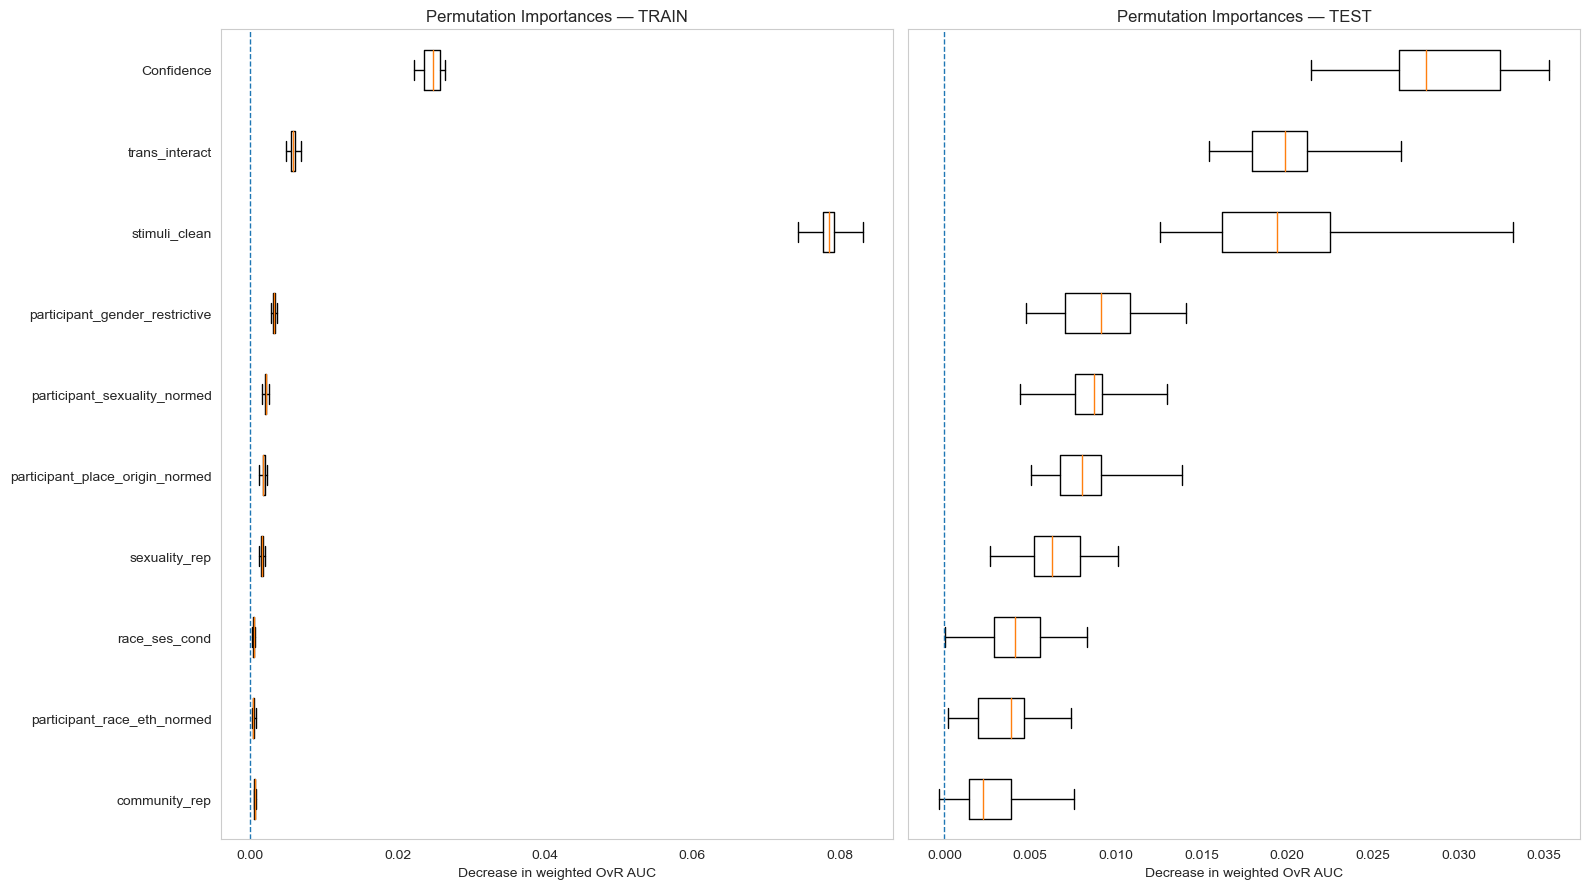

In [576]:
# --- Permutation importance train/test with AUC scoring ---
final_clf = gs.best_estimator_
final_clf.fit(X_train, y_train)

n_repeats = 20
scoring = 'roc_auc_ovr_weighted'
res_tr = permutation_importance(final_clf, X_train, y_train,
                                n_repeats=n_repeats, random_state=42, n_jobs=-1, scoring=scoring)
res_te = permutation_importance(final_clf, X_test,  y_test,
                                n_repeats=n_repeats, random_state=42, n_jobs=-1, scoring=scoring)

imp_tr_df = pd.DataFrame(res_tr.importances.T, columns=X_train.columns)
imp_te_df = pd.DataFrame(res_te.importances.T, columns=X_test.columns)

test_means = imp_te_df.mean(axis=0).sort_values(ascending=False)
top_k = 10
cols = [c for c in list(test_means.index[:top_k]) if (c in imp_tr_df.columns and c in imp_te_df.columns)]
if not cols:
    raise ValueError("No overlapping columns between train/test permutation outputs.")

data_tr = [imp_tr_df[c].values for c in cols][::-1]
data_te = [imp_te_df[c].values for c in cols][::-1]
labels  = cols[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 9), sharey=True)
for ax in axes:
    ax.grid(False)
axes[0].boxplot(data_tr, vert=False, whis=10, labels=labels)
axes[0].set_title("Permutation Importances — TRAIN")
axes[0].set_xlabel("Decrease in weighted OvR AUC")
axes[0].axvline(x=0, linestyle='--', linewidth=1)

axes[1].boxplot(data_te, vert=False, whis=10, labels=[''] * len(labels))
axes[1].set_title("Permutation Importances — TEST")
axes[1].set_xlabel("Decrease in weighted OvR AUC")
axes[1].axvline(x=0, linestyle='--', linewidth=1)

plt.subplots_adjust(left=0.35)
plt.tight_layout()
plt.show()

#### Prediction counts

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

classes = list(final_clf.classes_)

def counts_by_group(X, y_pred, group_col, *, all_levels=None, class_order=None):
    """Return a tidy DataFrame of counts by predicted label × group."""
    df = pd.DataFrame({group_col: X[group_col], "pred": y_pred})
    counts = (
        df.groupby(["pred", group_col])
          .size()
          .rename("count")
          .reset_index()
    )

    if class_order is None:
        class_order = sorted(counts["pred"].unique().tolist())
    if all_levels is None:
        all_levels = sorted(df[group_col].dropna().unique().tolist())

    mi = pd.MultiIndex.from_product([class_order, all_levels],
                                    names=["pred", group_col])
    counts_full = (
        counts.set_index(["pred", group_col])
              .reindex(mi, fill_value=0)
              .reset_index()
    )
    return counts_full, class_order, all_levels


# def barplot_separate_tab20(
#     X, y_pred, group_col, title,
#     *, all_levels=None, class_order=None, figsize=(14, 8)
# ):
#     """Draws a horizontal grouped barplot (tab20 palette) with custom size and frequency-sorted y-axis."""
#     tidy, class_order, all_levels = counts_by_group(
#         X, y_pred, group_col, all_levels=all_levels, class_order=class_order
#     )

#     # --- Sort predicted labels (y-axis) by total frequency descending ---
#     totals = tidy.groupby("pred")["count"].sum().sort_values(ascending=False)
#     class_order = totals.index.tolist()

#     # --- Consistent color palette (tab20) ---
#     palette = dict(zip(all_levels, sns.color_palette("tab20", n_colors=len(all_levels))))

#     plt.figure(figsize=figsize)
#     ax = sns.barplot(
#         data=tidy,
#         x="count",
#         y="pred",
#         hue=group_col,
#         order=class_order,
#         hue_order=all_levels,
#         orient="h",
#         palette=palette,
#         edgecolor="none"
#     )

#     ax.set_title(title, fontsize=12)
#     ax.set_xlabel("Count of predicted sexuality_label")
#     ax.set_ylabel("Predicted sexuality_label")
#     ax.legend(title=group_col, bbox_to_anchor=(1.05, 1), loc="upper left")
#     plt.tight_layout()
#     plt.subplots_adjust(right=0.75)
#     plt.show()

def barplot_separate_tab20(
    X, y_pred, group_col, title,
    *, all_levels=None, class_order=None, figsize=(14, 8),
    top_n=10  # <-- NEW PARAM
):
    """Draws a horizontal grouped barplot (tab20 palette) with custom size and frequency-sorted y-axis (optionally top N)."""
    tidy, class_order, all_levels = counts_by_group(
        X, y_pred, group_col, all_levels=all_levels, class_order=class_order
    )

    # --- Sort predicted labels (y-axis) by total frequency descending ---
    totals = tidy.groupby("pred")["count"].sum().sort_values(ascending=False)
    class_order = totals.index.tolist()

    # --- Keep only top N (default = 10) ---
    if top_n is not None and len(class_order) > top_n:
        class_order = class_order[:top_n]
        tidy = tidy[tidy["pred"].isin(class_order)]

    # --- Consistent color palette (tab20) ---
    palette = dict(zip(all_levels, sns.color_palette("tab20", n_colors=len(all_levels))))

    plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=tidy,
        x="count",
        y="pred",
        hue=group_col,
        order=class_order,
        hue_order=all_levels,
        orient="h",
        palette=palette,
        edgecolor="none"
    )

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Count of predicted combined forced-choice label")
    ax.set_ylabel("Predicted combined forced-choice label")
    ax.legend(title=group_col, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.subplots_adjust(right=0.75)
    plt.show()

# === EXAMPLES ===

# # (rounded 1–7, 0.5 increments)
# X_comm = X_test.copy()
# X_comm["trans_interact"] = X_comm["trans_interact"].astype(float).round(1)
# comm_levels = [round(x, 1) for x in np.arange(1.0, 7.0 + 0.5, 0.5)]

barplot_separate_tab20(
    X_test, y_pred,
    group_col="stimuli_clean",
    title="Predicted combined forced-choice counts by stimulus",
    class_order=classes,
    figsize=(12, 9)
)

barplot_separate_tab20(
    X_test, y_pred,
    group_col="trans_interact",
    title="Predicted combined forced-choice counts by interaction with trans people",
    class_order=classes,
    figsize=(12, 6)
)

barplot_separate_tab20(
    X_test, y_pred,
    group_col="queer_interact",
    title="Predicted combined forced-choice counts by interaction with queer people",
    class_order=classes,
    figsize=(12, 5)
)

barplot_separate_tab20(
    X_test, y_pred,
    group_col="personal_rep",
    title="Predicted combined forced-choice counts by accuracy of representation of partcipant sexuality",
    class_order=classes,
    figsize=(12, 7)
)

NameError: name 'val_pred_df' is not defined

### Visualize forest

Tree indices shown: [  0  99 199 299 399 499 599 699 799]
Mini-forest (subset) vote for sample 0
true label: non-binary_lesbian
subset majority: non-binary_lesbian (5 / 9, 0.56)


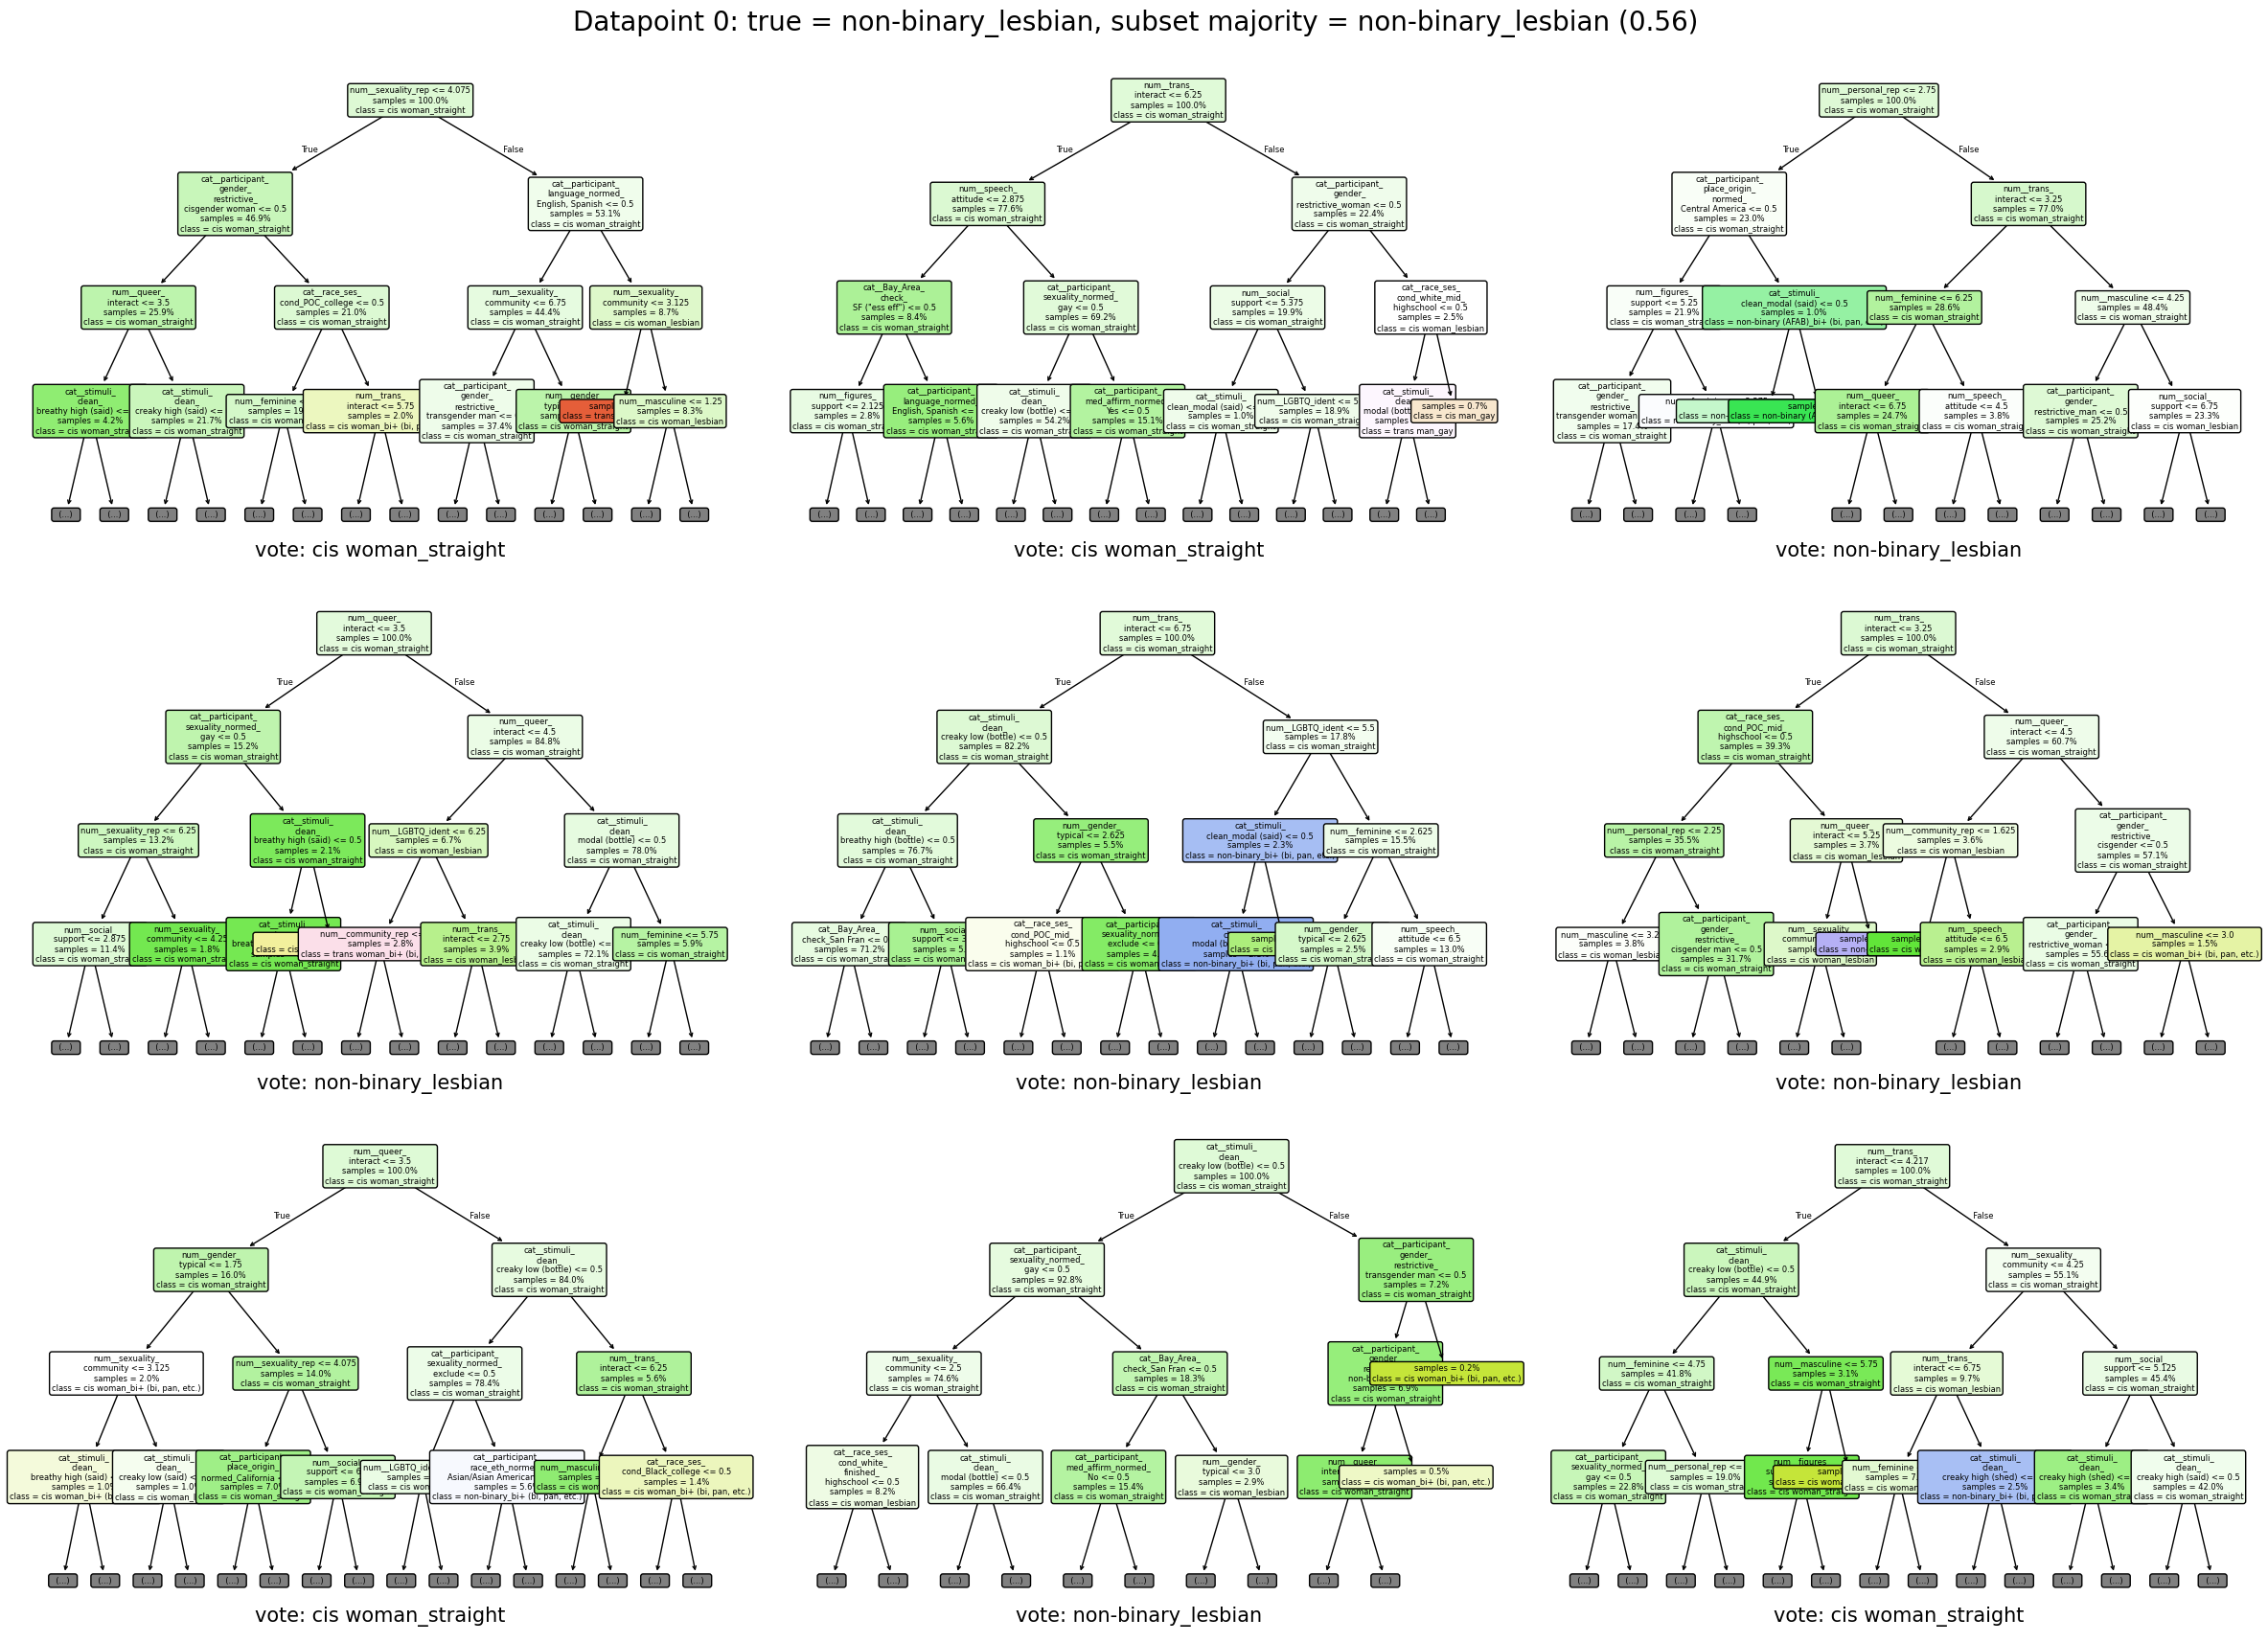

In [120]:
from sklearn import tree
import numpy as np
import matplotlib.pyplot as plt

# --- 0) Grab the fitted RF and preprocessor from your pipeline ---
rf = final_clf.named_steps['rf']

pre_name = 'pre' if 'pre' in final_clf.named_steps else 'preprocessor'
pre = final_clf.named_steps[pre_name]
feat_names_raw = pre.get_feature_names_out()
class_names = [str(c) for c in final_clf.classes_]  # index 0..K-1

# Optional: wrap long feature names to avoid overlap
feat_names_wrapped = wrap_feature_names(feat_names_raw, max_width=18)

# --- 1) Choose which trees to visualize ---
n_rows, n_cols = 3, 3   # or 2, 3 if you really want 6 trees
n_plots = n_rows * n_cols
n_estimators = len(rf.estimators_)

idxs = np.linspace(0, n_estimators - 1, n_plots, dtype=int)
print("Tree indices shown:", idxs)

# --- 2) Choose a single datapoint to inspect ---
i = 0  # index into X_test; change as you like
x_one = X_test.iloc[[i]]         # keep as DataFrame
y_true = y_test.iloc[i]

# preprocess once
x_one_tr = pre.transform(x_one)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 18))
axes = axes.ravel()

plot_depth = 3  # show only first 3 layers (root + 2 splits)

subset_votes = []  # store each selected tree's vote (class index)

for ax, idx in zip(axes, idxs):
    est = rf.estimators_[idx]

    ax.set_title(f"Tree {idx}", fontsize=10)

    tree.plot_tree(
        est,
        feature_names=feat_names_wrapped,
        class_names=class_names,
        filled=True,
        rounded=True,
        fontsize=6,
        node_ids=False,
        impurity=False,
        proportion=True,
        max_depth=plot_depth,
        ax=ax,
    )

    strip_value_blocks(ax)

    # --- each tree's vote for this datapoint ---
    pred_idx = int(est.predict(x_one_tr)[0])   # 0..K-1
    subset_votes.append(pred_idx)

    pred_label = class_names[pred_idx]
    ax.text(
        0.5, 0.05,
        f"vote: {pred_label[:18]}",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=15,
    )

# turn off unused axes if any
for ax in axes[len(idxs):]:
    ax.axis('off')

subset_votes = np.array(subset_votes)
counts = np.bincount(subset_votes, minlength=len(class_names))
total = counts.sum()

maj_idx = counts.argmax()
maj_label = class_names[maj_idx]
maj_frac = counts[maj_idx] / total

print("Mini-forest (subset) vote for sample", i)
print("true label:", y_true)
print("subset majority:", maj_label, f"({counts[maj_idx]} / {total}, {maj_frac:.2f})")

# show this info on the figure
fig.suptitle(
    f"Datapoint {i}: true = {y_true}, "
    f"subset majority = {maj_label} ({maj_frac:.2f})",
    fontsize=20,
    y=0.95
)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave room for suptitle
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


FULL FOREST majority: cis woman_straight 453
SUBSET-FOREST majority: non-binary_lesbian 5


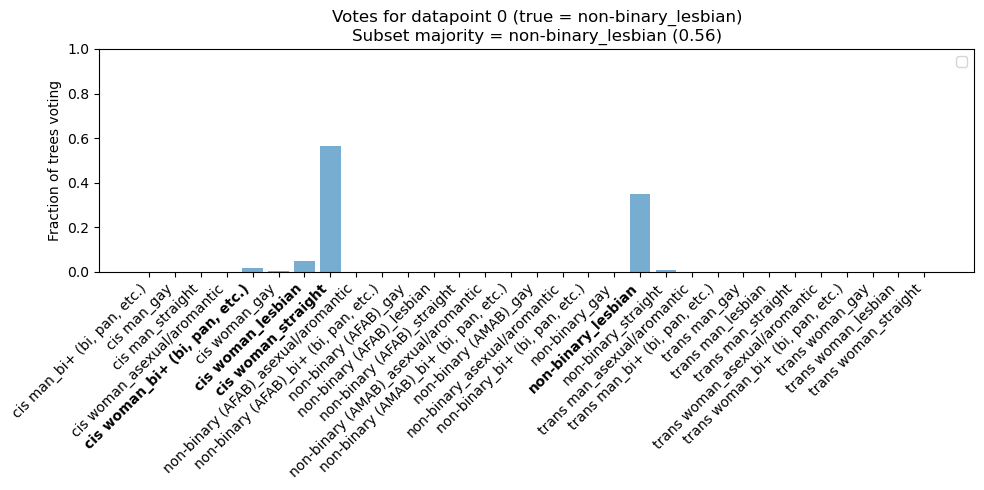

In [133]:
import numpy as np
import matplotlib.pyplot as plt

# --- Grab RF + preprocessor ---
rf = final_clf.named_steps['rf']
pre_name = 'pre' if 'pre' in final_clf.named_steps else 'preprocessor'
pre = final_clf.named_steps[pre_name]
class_names = [str(c) for c in final_clf.classes_]

# ============================================================
# 1. PICK THE SAME DATAPOINT AS BEFORE
# ============================================================

i = 0   # same index you used before
x_one = X_test.iloc[[i]]
y_true = y_test.iloc[i]

# preprocess once
x_one_tr = pre.transform(x_one)

# ============================================================
# 2. FULL FOREST VOTE ON THIS DATAPOINT
# ============================================================

tree_probs = []
tree_preds = []

for est in rf.estimators_:
    p = est.predict_proba(x_one_tr)[0]    # (n_classes,)
    tree_probs.append(p)
    tree_preds.append(np.argmax(p))

tree_probs = np.vstack(tree_probs)
tree_preds = np.array(tree_preds)

n_estimators = len(rf.estimators_)
vote_counts = np.bincount(tree_preds, minlength=len(class_names))
vote_frac   = vote_counts / n_estimators

majority_idx   = np.argmax(vote_counts)
majority_label = class_names[majority_idx]

print("FULL FOREST majority:", majority_label, vote_counts[majority_idx])

# ============================================================
# 3. SUBSET-OF-TREES VOTE (pretend these trees ARE the forest)
# ============================================================

# USE THE SAME TREE INDICES YOU PLOTTED IN THE MINI-FOREST
# Example: idxs = np.array([0, 10, 20, 30, 40, 50])  # ← replace with yours
# Or the 3×3 grid indices:
# idxs = np.linspace(0, n_estimators - 1, 9, dtype=int)

# <<< FILL THIS IN WITH YOUR SELECTED TREE INDICES >>>
idxs = [0, 99, 199, 299, 399, 499, 599, 699, 799]

subset_preds = []
for idx in idxs:
    est = rf.estimators_[idx]
    pred_idx = np.argmax(est.predict_proba(x_one_tr)[0])
    subset_preds.append(pred_idx)

subset_preds = np.array(subset_preds)

subset_counts = np.bincount(subset_preds, minlength=len(class_names))
subset_frac   = subset_counts / len(idxs)

subset_major_idx   = np.argmax(subset_counts)
subset_major_label = class_names[subset_major_idx]
subset_major_frac  = subset_frac[subset_major_idx]

print("SUBSET-FOREST majority:", subset_major_label, subset_counts[subset_major_idx])

# ============================================================
# 4. PLOT BOTH ON THE SAME BAR PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

# Full forest (filled bars)
ax.bar(class_names, vote_frac, alpha=0.6)

# # Subset forest (outlined bars)
# ax.bar(
#     class_names,
#     subset_frac,
#     label="Subset of selected trees",
#     alpha=0.0,
#     edgecolor='black',
#     linewidth=1.5
# )

# # Highlight subset majority class (red outline)
# ax.bar(
#     class_names[subset_major_idx],
#     subset_frac[subset_major_idx],
#     alpha=0.0,
#     edgecolor='red',
#     linewidth=2.5,
#     label=f"Subset majority = {subset_major_label}"
# )

ax.set_ylim(0, 1)
ax.set_ylabel("Fraction of trees voting")
ax.set_title(
    f"Votes for datapoint {i} (true = {y_true})\n"
    f"Subset majority = {subset_major_label} ({subset_major_frac:.2f})"
)

plt.xticks(rotation=45, ha="right")
# Bold the specific class, e.g. the subset majority class
highlight_classes = ["cis woman_straight", "non-binary_lesbian", "cis woman_lesbian", "cis woman_bi+ (bi, pan, etc.)"]

for tick_label, cls in zip(ax.get_xticklabels(), class_names):
    if cls in highlight_classes:
        tick_label.set_fontweight("bold")
plt.legend()
plt.tight_layout()
plt.show()

FULL FOREST majority: cis woman_straight 453


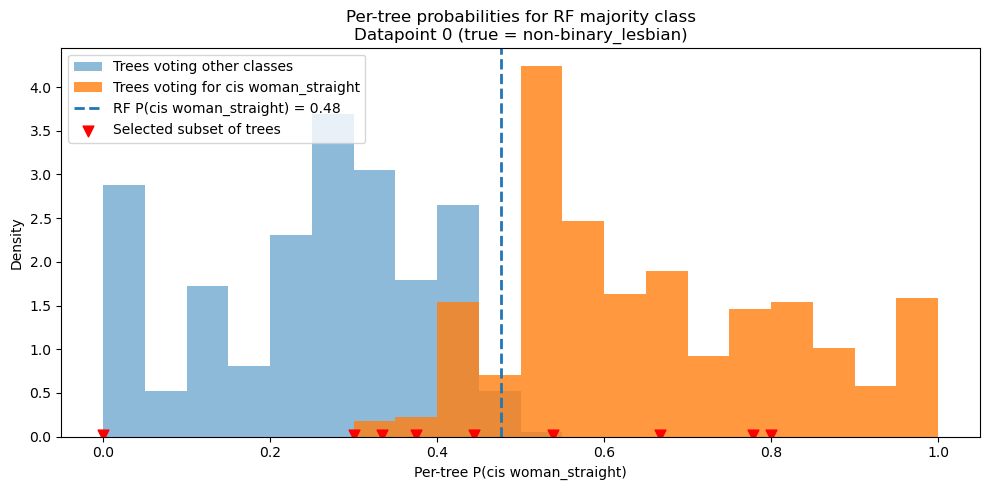

In [122]:
# --- 0) RF + Preprocessor ---
rf = final_clf.named_steps['rf']
pre_name = 'pre' if 'pre' in final_clf.named_steps else 'preprocessor'
pre = final_clf.named_steps[pre_name]
class_names = [str(c) for c in final_clf.classes_]

# ============================================================
# 1. PICK THE SAME DATAPOINT USED IN YOUR MINI-FOREST
# ============================================================

i = 0  # <<< choose the same datapoint index as before
x_one = X_test.iloc[[i]]
x_one_tr = pre.transform(x_one)
y_true = y_test.iloc[i]

# ============================================================
# 2. FULL-FOREST PREDICTIONS (all trees)
# ============================================================

tree_probs = []
tree_preds = []

for est in rf.estimators_:
    p = est.predict_proba(x_one_tr)[0]      # per-tree probability vector
    tree_probs.append(p)
    tree_preds.append(np.argmax(p))

tree_probs = np.vstack(tree_probs)          # (n_estimators, n_classes)
tree_preds = np.array(tree_preds)           # (n_estimators,)

n_estimators = len(rf.estimators_)

vote_counts = np.bincount(tree_preds, minlength=len(class_names))
majority_idx   = np.argmax(vote_counts)
majority_label = class_names[majority_idx]

# Probability from full RF (predict_proba averages tree probs)
rf_proba = final_clf.predict_proba(x_one)[0]
rf_prob_major = rf_proba[majority_idx]

print("FULL FOREST majority:", majority_label, vote_counts[majority_idx])

# ============================================================
# 3. SUBSET-OF-TREES (same trees you plotted earlier)
# ============================================================

# <<< Replace these with the indices of your 6 or 9 selected trees >>>
# Example: a 3×3 evenly spaced subset:
idxs = [0, 99, 199, 299, 399, 499, 599, 699, 799]

subset_prob_major = tree_probs[idxs, majority_idx]

# ============================================================
# 4. PREPARE HISTOGRAM DATA
# ============================================================

prob_major = tree_probs[:, majority_idx]              # per-tree prob for majority class
voted_for_majority = (tree_preds == majority_idx)     # boolean mask

bins = np.linspace(0, 1, 21)

# ============================================================
# 5. PLOT HISTOGRAM + SUBSET MARKERS
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

# Trees that did NOT vote for the majority class
ax.hist(
    prob_major[~voted_for_majority],
    bins=bins,
    alpha=0.5,
    label="Trees voting other classes",
    density=True
)

# Trees that DID vote for the majority class
ax.hist(
    prob_major[voted_for_majority],
    bins=bins,
    alpha=0.8,
    label=f"Trees voting for {majority_label}",
    density=True
)

# Vertical reference line for full RF probability
ax.axvline(
    rf_prob_major,
    linestyle="--",
    linewidth=2,
    label=f"RF P({majority_label}) = {rf_prob_major:.2f}"
)

# Mark subset trees
ax.scatter(
    subset_prob_major,
    np.zeros_like(subset_prob_major) + 0.02,   # just above x-axis
    color="red",
    marker="v",
    s=60,
    label="Selected subset of trees"
)

ax.set_xlabel(f"Per-tree P({majority_label})")
ax.set_ylabel("Density")
ax.set_title(
    f"Per-tree probabilities for RF majority class\n"
    f"Datapoint {i} (true = {y_true})"
)

ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

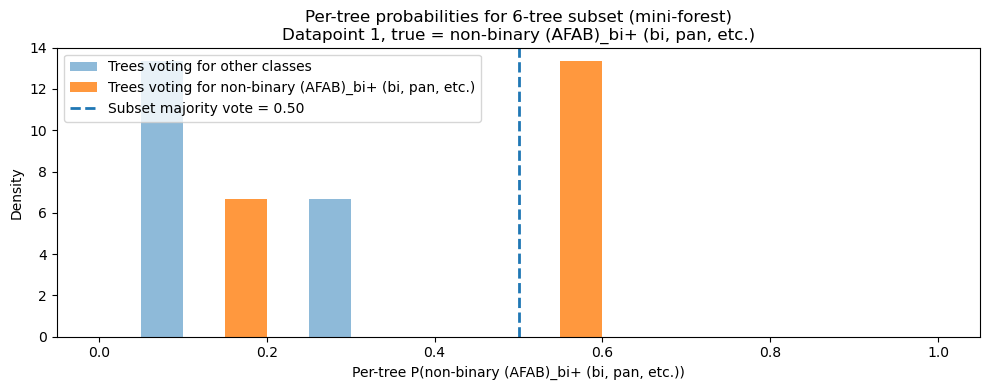

In [124]:
import numpy as np
import matplotlib.pyplot as plt

# --- 0) RF + Preprocessor ---
rf = final_clf.named_steps['rf']
pre_name = 'pre' if 'pre' in final_clf.named_steps else 'preprocessor'
pre = final_clf.named_steps[pre_name]
class_names = [str(c) for c in final_clf.classes_]

# ============================================================
# 1. PICK THE SAME DATAPOINT
# ============================================================

i = 1                    # <<< your datapoint
x_one = X_test.iloc[[i]]
x_one_tr = pre.transform(x_one)
y_true = y_test.iloc[i]

# ============================================================
# 2. SELECT THE SAME 6 TREES YOU VISUALIZED EARLIER
# ============================================================

# <<< Replace this with YOUR real six-tree subset >>>
n_estimators = len(rf.estimators_)
idxs = np.linspace(0, n_estimators - 1, 6, dtype=int)

# ============================================================
# 3. GET PER-TREE PROBABILITIES + VOTES FROM JUST THESE 6 TREES
# ============================================================

subset_probs = []
subset_preds = []

for idx in idxs:
    est = rf.estimators_[idx]
    p = est.predict_proba(x_one_tr)[0]     # probability vector
    subset_probs.append(p)
    subset_preds.append(np.argmax(p))

subset_probs = np.vstack(subset_probs)     # (6, n_classes)
subset_preds = np.array(subset_preds)      # (6,)

# Choose the majority class among the 6 trees
subset_counts = np.bincount(subset_preds, minlength=len(class_names))
subset_major_idx = np.argmax(subset_counts)
subset_major_label = class_names[subset_major_idx]

# Per-tree probability for THIS class
prob_major_subset = subset_probs[:, subset_major_idx]

# Which of your 6 trees voted for that class?
subset_voted_majority = (subset_preds == subset_major_idx)

# “Mini-forest probability” = fraction of 6 trees voting for the majority
subset_major_prob = subset_counts[subset_major_idx] / len(idxs)

# ============================================================
# 4. HISTOGRAM — SAME STYLE AS BEFORE, BUT ONLY THE 6 TREES
# ============================================================

bins = np.linspace(0, 1, 21)
fig, ax = plt.subplots(figsize=(10, 4))

# Trees that did NOT vote for this class
ax.hist(
    prob_major_subset[~subset_voted_majority],
    bins=bins,
    alpha=0.5,
    label="Trees voting for other classes",
    density=True,
)

# Trees that voted FOR the 6-tree majority class
ax.hist(
    prob_major_subset[subset_voted_majority],
    bins=bins,
    alpha=0.8,
    label=f"Trees voting for {subset_major_label}",
    density=True,
)

# Vertical line for the 6-tree majority vote probability
ax.axvline(
    subset_major_prob,
    linestyle="--",
    linewidth=2,
    label=f"Subset majority vote = {subset_major_prob:.2f}"
)

ax.set_xlabel(f"Per-tree P({subset_major_label})")
ax.set_ylabel("Density")
ax.set_title(
    f"Per-tree probabilities for 6-tree subset (mini-forest)\n"
    f"Datapoint {i}, true = {y_true}"
)

plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

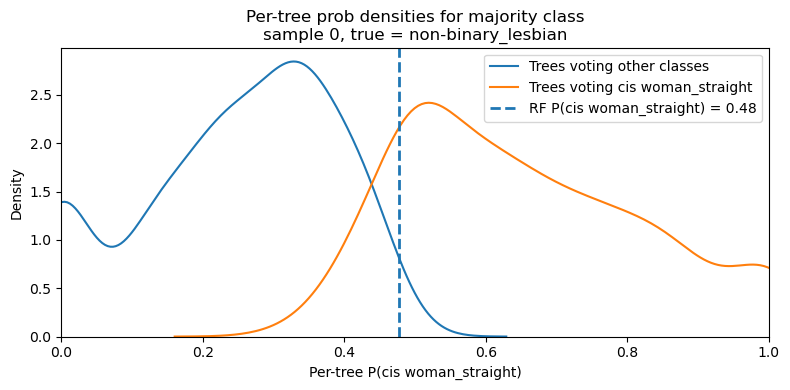

In [97]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 4))

sns.kdeplot(prob_major[~voted_for_majority], ax=ax, label="Trees voting other classes")
sns.kdeplot(prob_major[voted_for_majority], ax=ax, label=f"Trees voting {majority_label}")

ax.axvline(rf_prob_major, linestyle="--", linewidth=2,
           label=f"RF P({majority_label}) = {rf_prob_major:.2f}")

ax.set_xlim(0, 1)
ax.set_xlabel(f"Per-tree P({majority_label})")
ax.set_ylabel("Density")
ax.set_title(f"Per-tree prob densities for majority class\nsample {i}, true = {y_test.iloc[i]}")
ax.legend()
plt.tight_layout()
plt.show()
